# The HR diagram   (...and the importance of data scaling in machine learning)

This assignment is about stars...

We will work with a star catalogue of 240 stars described by the following information:

- Temperature (in Kelvin)
- Luminosity (L/Lo)
- Radius (R/Ro)
- Absolute magnitude (Mv)

We also have the following data for each star:

- Color (Red/Orange/Yellow/White/Blue)
- Spectral class ('A', 'B', 'F', 'G', 'K', 'M', 'O')
- Star type (Brown dwarf/Red dwarf/White dwarf/Main sequence/Supergiant/Hypergiant)

This dataset has been collected by [Deepraj Baidya](https://github.com/deepraj1729) and was originally published on [Kaggle](https://www.kaggle.com/deepu1109/star-dataset). 

In [152]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x21117515290>)

I'll take this as an opportunity to introduce `pandas` and `seaborn`, which are popular python packages. The are similar to `numpy` and `matplotlib`, but newer. I personally prefer my good old numpy, but these are *very* popular, so here is something you can do with them. 

In [153]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")

In [154]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


There are 6 star types that are encoded in the *'Star type'* column. These labels are currently encoded as strings which is practical for reading but not for computing. Using scikit-learn, we will convert this column into integers by assigning a unique int value to each star type.

In [155]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)


df_stars['Star color'] = le.fit_transform(df_stars['Star color'])
df_stars['Spectral Class'] = le.fit_transform(df_stars['Spectral Class'])

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


We've seen this already last time. It is often grood practice to start with a statistical analysis of the dataset to answer the following questions:
* are there any missing values?
* are there NaNs in the data?

In [156]:
print(df_stars.isnull().sum())
print("Contains NaN?", df_stars.isna().any().any())

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64
Contains NaN? False


Star classification is something that can be done based on rules depending on temperature and luminosity. For example, Wikipedia gives the following example of a Hertzsprung-Russell diagram:
![](https://upload.wikimedia.org/wikipedia/commons/6/6b/HRDiagram.png)

We can reproduce this diagram by plotting the scatter plot of our stars using the same variables in log-log-scale.

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

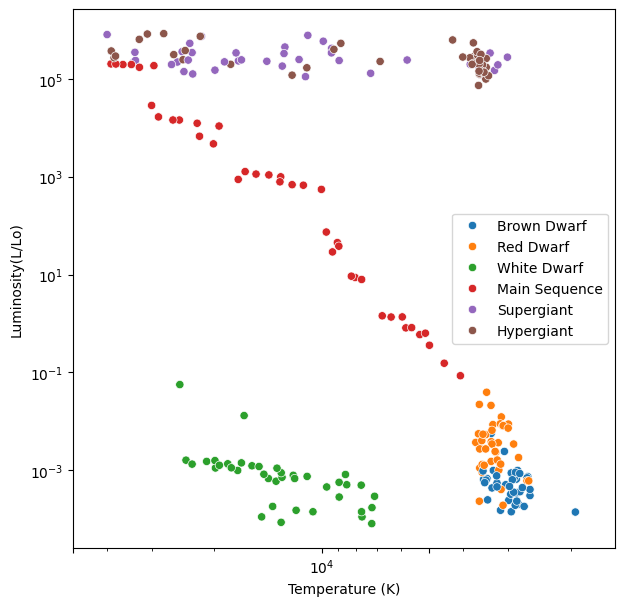

In [158]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

We find the same organization of stars in this 2D plane. Main Sequence stars and White Dwarves are fairly easy to isolate from the rest: a statistical model should be able to easily classify them. Based only on Luminosity and Temperature, Dwarf stars and Giant stars have higher intra-group variability: Supergiant and Hypergiant cover the same space (same for Brown and Red Dwarves). Additionnal variables might be needed to correctly identify the types of those stars.

- Apply PCA to the dataset at your disposal (hint: don't use columns with labels, only those with real numbers).
- Project the dataset into the principal components, and do a scatter plot of the first two. 
- This will look terrible. Think about the units!
- Explore what happens if you rescale the data first.

**This is actually a very important lesson in machine learning**: Massaging your data before giving them to an algorithm can make things much much better.

- You can try an linear, affine transformation such that each dimension goes between -1 and 1.
- Or (which is [the usual machine-learning approach](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)) standardize your data such that each dimension has mean=0 and variance=1. 
- Redo your PCA. Should be much much better.
- How much variance is explained by those two components?


### For later: come back to this assignment after lecture 20
- Now run a supervised classification algorithm on this dataset. 
- Can you predict the stellar type? How well? Careful with overfitting of course.

In [ ]:
# Choose only the numerical columns
features = ['Temperature (K)',	'Luminosity(L/Lo)',	'Radius(R/Ro)',	'Absolute magnitude(Mv)']
X = df_stars[features]#

X_log = df_stars[features].copy()

# Applica log10 a Temperature e Luminosity
X_log['Temperature (K)'] = np.log10(X_log['Temperature (K)'])
X_log['Luminosity(L/Lo)'] = np.log10(X_log['Luminosity(L/Lo)'])  # per evitare log(0)
X_log['Radius(R/Ro)'] = np.log10(X_log['Radius(R/Ro)'])
#X = X_log

n_comp = 2

### Raw Data

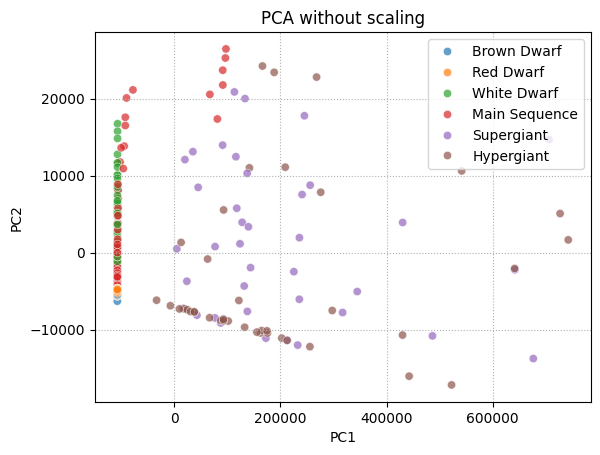

Explained variance ratio: [0.99760631 0.0023879 ]
Total variance explained by PC1 and PC2: 0.9999942118846565


In [218]:
from sklearn.decomposition import PCA

# Apply PCA directly
pca = PCA(n_components=n_comp)
X_pca_raw = pca.fit_transform(X)

# Plot the result
sns.scatterplot(x=X_pca_raw[:, 0], y=X_pca_raw[:, 1], alpha=0.7, hue = labels)
plt.title("PCA without scaling")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(linestyle = ":")
plt.show()

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained by PC1 and PC2:", sum(pca.explained_variance_ratio_))

This plot looks bad, because the features have very different units (like Kelvin vs. magnitudes).

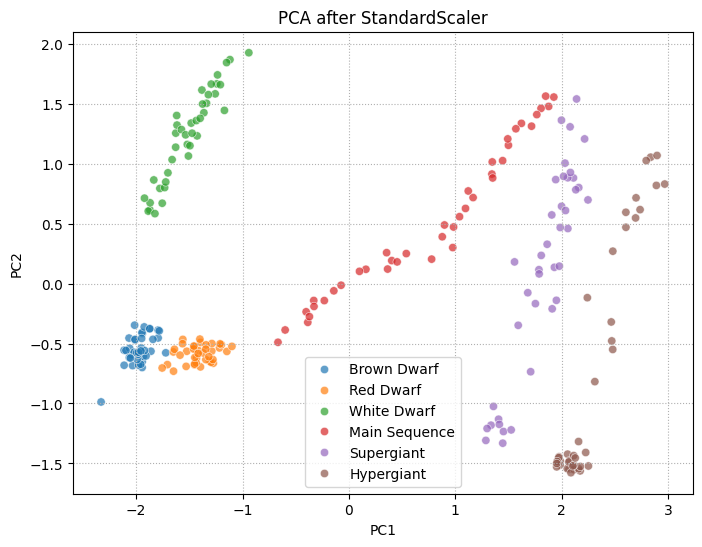

Explained variance (scaled): [0.76162934 0.22012559]
Total variance explained by PC1 and PC2: 98.18%


In [237]:
from sklearn.preprocessing import StandardScaler

# Scale the data: mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Apply PCA again
pca_scaled = PCA(n_components=n_comp)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)
X_original = scaler.inverse_transform(X_scaled)

# Plot again
fig = plt.figure(figsize=(8, 6))
sns.scatterplot(x = X_pca_scaled[:, 0], y = X_pca_scaled[:, 1], hue = labels, alpha=0.7)
plt.title("PCA after StandardScaler")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(linestyle = ":")
plt.show()


# Print explained variance
explained = pca_scaled.explained_variance_ratio_
print("Explained variance (scaled):", explained)
print(f"Total variance explained by PC1 and PC2: {explained.sum() * 100:.2f}%")


### MinMaxScaler [-1, 1]

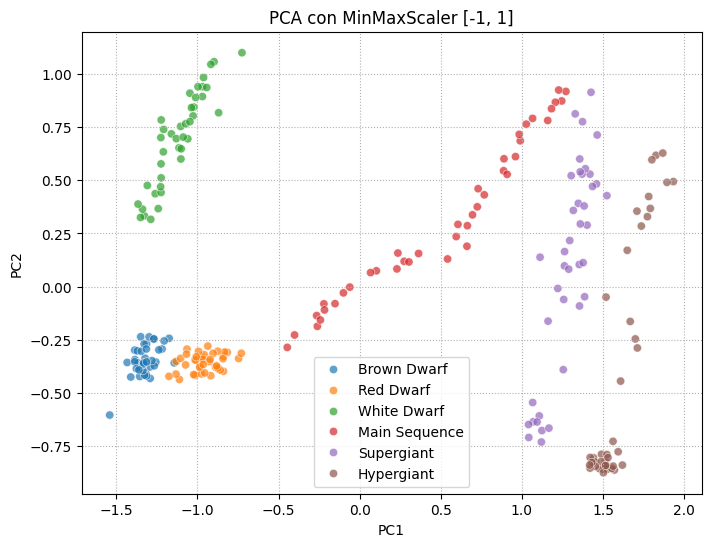

Explained variance (MinMaxScaler): [0.81793824 0.16334749]
Total variance explained by PC1 and PC2: 98.13%


In [238]:
from sklearn.preprocessing import MinMaxScaler

# Rescaling tra -1 e 1
minmax_scaler = MinMaxScaler(feature_range=(-1, 1))
X_minmax = minmax_scaler.fit_transform(X_log)

# PCA dopo MinMaxScaler
pca_minmax = PCA(n_components=n_comp)
X_pca_minmax = pca_minmax.fit_transform(X_minmax)
# Rescale back to original units
X_original_minmax = minmax_scaler.inverse_transform(X_minmax)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x = X_pca_minmax[:, 0], y = X_pca_minmax[:, 1], hue = labels, alpha=0.7)
plt.title("PCA con MinMaxScaler [-1, 1]")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(linestyle = ":")
#plt.xscale('log')
#plt.yscale('log')
plt.show()

# Varianza spiegata
explained_var_minmax = pca_minmax.explained_variance_ratio_
print("Explained variance (MinMaxScaler):", explained_var_minmax)
print(f"Total variance explained by PC1 and PC2: {explained_var_minmax.sum() * 100:.2f}%")

### Numbr of components:

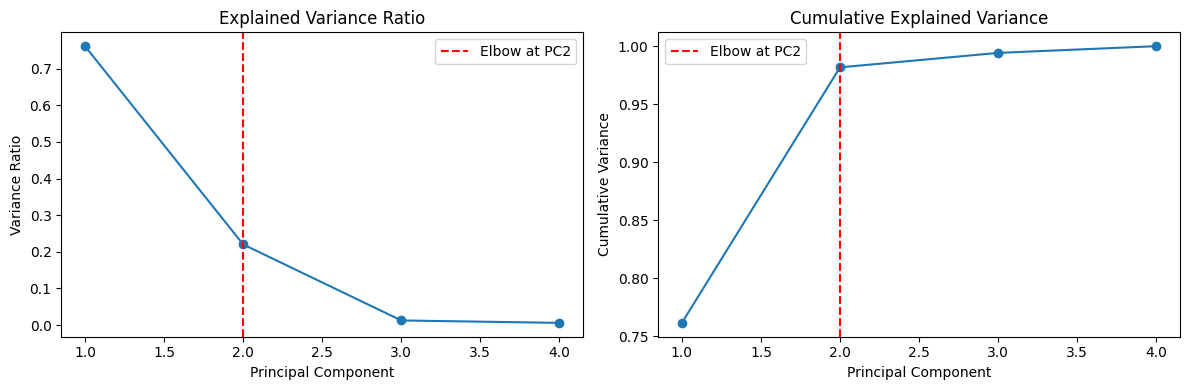

In [239]:
n = X.shape[1]
pca = PCA(n_components=n)
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

# Soglia della varianza spiegata (90%)
threshold = 0.90
elbow_index = np.argmax(cumulative_var >= threshold) + 1  # +1 because of the 0-indexed array

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Explained variance
axes[0].plot(range(1, n+1), explained_var, marker='o')
axes[0].axvline(elbow_index, color='red', linestyle='--', label=f"Elbow at PC{elbow_index}")
axes[0].set_title("Explained Variance Ratio")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Ratio")
axes[0].legend()

# Cumulative explained variance
axes[1].plot(range(1, n+1), cumulative_var, marker='o')
axes[1].axvline(elbow_index, color='red', linestyle='--', label=f"Elbow at PC{elbow_index}")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Cumulative Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

# Unsupervsed Clustering - KMeans

### StandardScaler

In [240]:
from sklearn.cluster import KMeans

# Applichiamo il clustering
k = 6  # puoi variare questo numero!
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_pca_scaled)

# Aggiungiamo il cluster al DataFrame
df_stars['Cluster'] = clusters


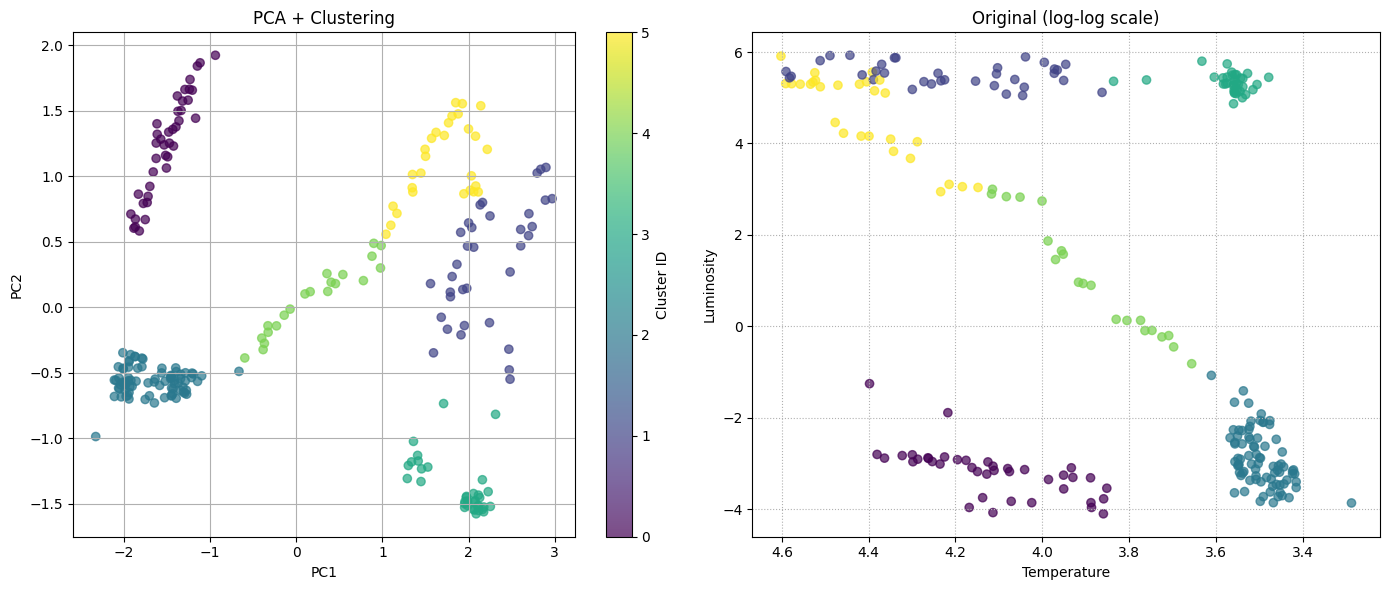

In [241]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: PCA space ---
scatter1 = axes[0].scatter(X_pca_scaled[:, 0], X_pca_scaled[:, 1], c=clusters, alpha=0.7)
axes[0].set_title("PCA + Clustering")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

# Add colorbar to the first plot only
cbar = fig.colorbar(scatter1, ax=axes[0], label='Cluster ID')

# --- Plot 2: Original (HR-like) space ---
scatter2 = axes[1].scatter(X_original[:, 0], X_original[:, 1], c=clusters, alpha=0.7)
axes[1].set_title("Original (log-log scale)")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Luminosity")
axes[1].grid(True, linestyle=':')

# Log scale + reverse x
#axes[1].set_xscale('log')
#axes[1].set_yscale('log')
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()


### MinMaxScaler [-1, 1]

In [242]:
# Applichiamo il clustering
k = 6  # puoi variare questo numero!
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_pca_minmax)

# Aggiungiamo il cluster al DataFrame
df_stars['Cluster'] = clusters

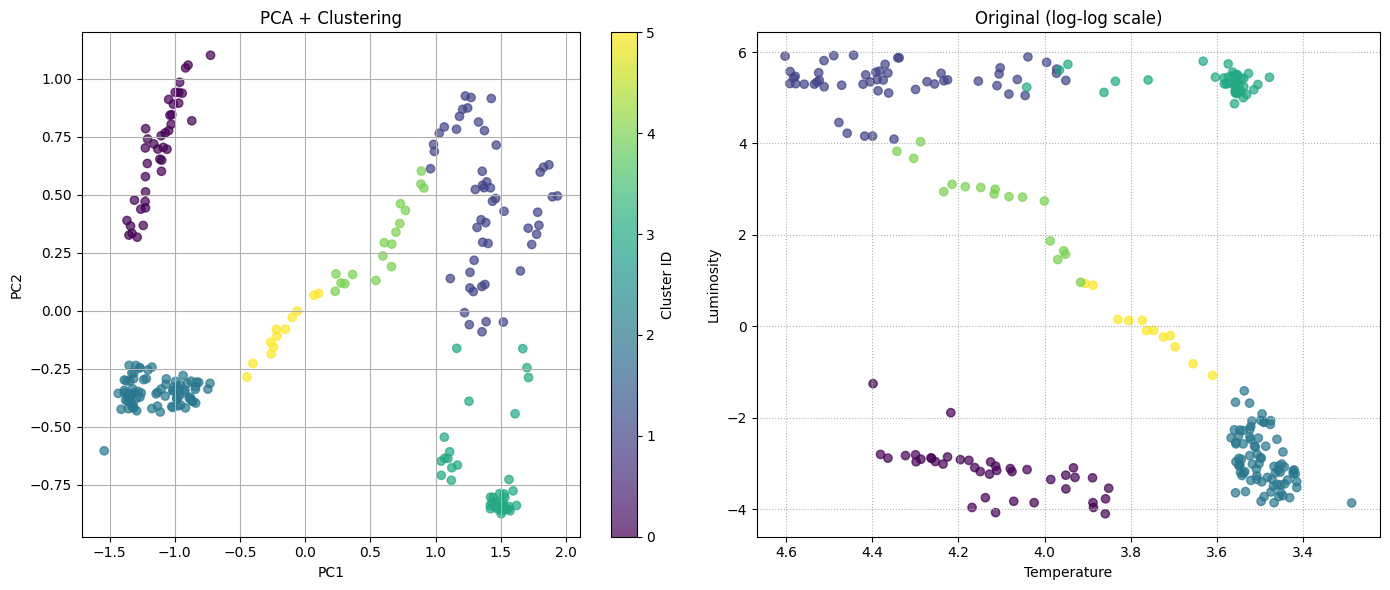

In [243]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: PCA space ---
scatter1 = axes[0].scatter(X_pca_minmax[:, 0], X_pca_minmax[:, 1], c=clusters, alpha=0.7)
axes[0].set_title("PCA + Clustering")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

# Add colorbar to the first plot only
cbar = fig.colorbar(scatter1, ax=axes[0], label='Cluster ID')

# --- Plot 2: Original (HR-like) space ---
scatter2 = axes[1].scatter(X_original[:, 0], X_original[:, 1], c=clusters, alpha=0.7)
axes[1].set_title("Original (log-log scale)")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Luminosity")
axes[1].grid(True, linestyle=':')

# Log scale + reverse x
#axes[1].set_xscale('log')
#axes[1].set_yscale('log')
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()


# Supervsed Clustering - LogisticRegression

In [246]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [247]:
# Target labels (the star types)
y = df_stars['Star type']

In [256]:
# Splitting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.7)

In [257]:
model = LogisticRegression(solver='saga', max_iter=10000, C=50)

clf = model.fit(X_train, y_train)
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

In [258]:
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy training set: {acc_train:.3f}")
print(f"Accuracy validation set: {acc_test:.3f}")

Accuracy training set: 1.000
Accuracy validation set: 0.952


In [233]:
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)

print("Confusion Matrix - Training Set")
print(cm_train)
print("\nConfusion Matrix - Test Set")
print(cm_test)

Confusion Matrix - Training Set
[[10  0  0  0  0  0]
 [ 0 12  0  0  0  0]
 [ 0  0 12  0  0  0]
 [ 0  0  0 15  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0 13]]

Confusion Matrix - Test Set
[[30  0  0  0  0  0]
 [ 0 25  0  0  3  0]
 [ 0  0 26  2  0  0]
 [ 0  0  0 25  0  0]
 [ 0  0  1  0 29  0]
 [ 0  0  0  0  0 27]]


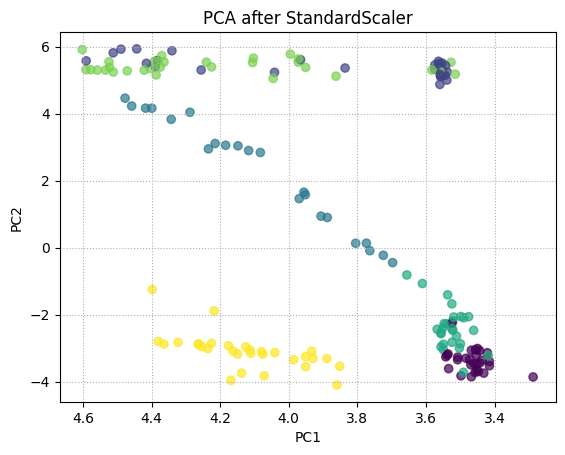

In [259]:
X_original_test = scaler.inverse_transform(X_test)

# Plot again
plt.scatter(X_original_test[:, 0], X_original_test[:, 1],  c=y_pred_test, alpha=0.7)
plt.title("PCA after StandardScaler")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(linestyle = ":")
#plt.xscale('log')
#plt.yscale('log')
plt.gca().invert_xaxis()

plt.show()
